#1. Import and Config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# EXPERIMENT A1 — Unfiltered + Metadata + TF-IDF
# Dataset : yelp_nyc_processed_v2.csv (359,052 rows, unfiltered)
# Features: TF-IDF (3000) + metadata (6) = 3006 features
# Models  : Logistic Regression, LightGBM
# Imbalance: class_weight="balanced" (LR), scale_pos_weight (LGBM)
# Tuning  : small hyperparameter grid on validation set
# Threshold: tuned on validation set, applied once on test set
#
# Research question:
#   Unfiltered baseline — text + metadata only, no behavioral features.
#   Compare against B1 (filtered, no behavioral) and
#   B2 (filtered + behavioral) to quantify the filtering
#   vs behavioral features tradeoff.
#
# NOTE: Hyperparameters and thresholds are jointly optimised
#       on the validation set only. Final performance is reported
#       on the held-out test set, touched exactly once at the end.
# ============================================================

# ── INSTALLS (run once in Colab) ─────────────────────────────
# !pip install lightgbm --quiet

# ── IMPORTS ──────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, make_scorer
)
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130

# ── CONFIGURATION ────────────────────────────────────────────
SEED       = 42
DATA_PATH  = "/content/drive/MyDrive/FakeReviewProject/"
EXP_PATH   = DATA_PATH + "experiment_a1/"
MODEL_PATH = EXP_PATH  + "models/"

os.makedirs(MODEL_PATH, exist_ok=True)
np.random.seed(SEED)

# Explicit fake-class F1 scorer for GridSearchCV
# make_scorer is safer than scoring="f1" which can be ambiguous
f1_fake = make_scorer(f1_score, pos_label=1)

# Metadata columns
# review_year deliberately excluded — acts as a proxy for
# time-based data drift, not a genuine fake review signal
META_COLS = [
    "rating",
    "review_length",
    "extreme_rating",
    "review_month",
    "review_dayofweek",
    "is_weekend",
]

#2. Load Data

In [3]:
print("=" * 60)
print("1. LOADING DATA")
print("=" * 60)

df = pd.read_csv(DATA_PATH + "yelp_nyc_processed_v2.csv",
                 parse_dates=["review_date"])
df = df.reset_index(drop=True)

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")

vc = df["label"].value_counts()
print(f"\nClass distribution (full dataset):")
print(f"  Genuine (0) : {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)")
print(f"  Fake    (1) : {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)")

required = ["label", "text_clean"] + META_COLS
missing  = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")
print("\nSchema check passed")

1. LOADING DATA
Shape  : (359052, 13)
Columns: ['reviewer_id', 'product_id', 'rating', 'label', 'review_date', 'text', 'text_clean', 'review_length', 'review_year', 'review_month', 'review_dayofweek', 'is_weekend', 'extreme_rating']

Class distribution (full dataset):
  Genuine (0) : 322,167 (89.7%)
  Fake    (1) : 36,885 (10.3%)

Schema check passed


# ============================================================
# 2. TRAIN / VALIDATION / TEST SPLIT
# ============================================================
# Split BEFORE fitting any preprocessing.
# All preprocessing objects (TF-IDF, scaler) are fit on
# train only, then applied to val and test.
#
# 70% train | 15% validation | 15% test
# Validation : hyperparameter selection, threshold tuning,
#              LightGBM early stopping
# Test       : final evaluation only, touched once
# ============================================================

In [4]:
print("\n" + "=" * 60)
print("2. TRAIN / VALIDATION / TEST SPLIT  (70 / 15 / 15)")
print("=" * 60)

y   = df["label"].values
idx = np.arange(len(y))

# First split: 70% train, 30% temp
idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Second split: 30% temp → 15% val + 15% test
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# Save indices — B1 and B2 use their own splits,
# but these are saved for reproducibility of A1
np.save(MODEL_PATH + "idx_train.npy", idx_train)
np.save(MODEL_PATH + "idx_val.npy",   idx_val)
np.save(MODEL_PATH + "idx_test.npy",  idx_test)

def split_summary(name, y_split):
    n  = len(y_split)
    nf = int(y_split.sum())
    ng = n - nf
    print(f"  {name:12s}: {n:,} | "
          f"Genuine: {ng:,} ({ng/n*100:.1f}%) | "
          f"Fake: {nf:,} ({nf/n*100:.1f}%)")

split_summary("Train",      y_train)
split_summary("Validation", y_val)
split_summary("Test",       y_test)
print(f"\nSaved: idx_train.npy, idx_val.npy, idx_test.npy")


2. TRAIN / VALIDATION / TEST SPLIT  (70 / 15 / 15)
  Train       : 251,336 | Genuine: 225,517 (89.7%) | Fake: 25,819 (10.3%)
  Validation  : 53,858 | Genuine: 48,325 (89.7%) | Fake: 5,533 (10.3%)
  Test        : 53,858 | Genuine: 48,325 (89.7%) | Fake: 5,533 (10.3%)

Saved: idx_train.npy, idx_val.npy, idx_test.npy


# ============================================================
# 3. TF-IDF FEATURES
# ============================================================
# TF-IDF is fit on TRAIN TEXT ONLY — no leakage.
# The fitted vectorizer and matrix are cached to Drive.
# Subsequent runs load from cache — no recomputation needed.
#
# Cache files:
#   tfidf_vectorizer.pkl   — fitted vectorizer
#   X_tfidf_train.npz      — train sparse matrix
#   X_tfidf_val.npz        — val sparse matrix
#   X_tfidf_test.npz       — test sparse matrix
# ============================================================

In [5]:
print("\n" + "=" * 60)
print("3. TF-IDF FEATURES")
print("=" * 60)

TFIDF_VEC_CACHE   = MODEL_PATH + "tfidf_vectorizer.pkl"
TFIDF_TRAIN_CACHE = MODEL_PATH + "X_tfidf_train.npz"
TFIDF_VAL_CACHE   = MODEL_PATH + "X_tfidf_val.npz"
TFIDF_TEST_CACHE  = MODEL_PATH + "X_tfidf_test.npz"

all_caches_exist = all(os.path.exists(p) for p in [
    TFIDF_VEC_CACHE,
    TFIDF_TRAIN_CACHE,
    TFIDF_VAL_CACHE,
    TFIDF_TEST_CACHE,
])

if all_caches_exist:
    print("Loading cached TF-IDF matrices...")
    tfidf       = joblib.load(TFIDF_VEC_CACHE)
    X_tfidf_train = sp.load_npz(TFIDF_TRAIN_CACHE)
    X_tfidf_val   = sp.load_npz(TFIDF_VAL_CACHE)
    X_tfidf_test  = sp.load_npz(TFIDF_TEST_CACHE)
    print(f"Loaded train : {X_tfidf_train.shape}")
    print(f"Loaded val   : {X_tfidf_val.shape}")
    print(f"Loaded test  : {X_tfidf_test.shape}")

else:
    print("Computing TF-IDF (fit on train only)...")

    train_texts = df.iloc[idx_train]["text_clean"].fillna("").tolist()
    val_texts   = df.iloc[idx_val]["text_clean"].fillna("").tolist()
    test_texts  = df.iloc[idx_test]["text_clean"].fillna("").tolist()

    tfidf = TfidfVectorizer(
        max_features=3000,
        min_df=5,           # ignore terms in fewer than 5 train docs
        max_df=0.95,        # ignore terms in more than 95% of train docs
        ngram_range=(1, 2), # unigrams + bigrams
        sublinear_tf=True,  # log(1+tf) — reduces dominance of frequent terms
        strip_accents="unicode",
        analyzer="word",
        token_pattern=r"\b[a-zA-Z]{2,}\b"
    )

    # Fit on train only, transform all three splits
    X_tfidf_train = tfidf.fit_transform(train_texts)
    X_tfidf_val   = tfidf.transform(val_texts)
    X_tfidf_test  = tfidf.transform(test_texts)

    # Cache everything to Drive
    joblib.dump(tfidf, TFIDF_VEC_CACHE)
    sp.save_npz(TFIDF_TRAIN_CACHE, X_tfidf_train)
    sp.save_npz(TFIDF_VAL_CACHE,   X_tfidf_val)
    sp.save_npz(TFIDF_TEST_CACHE,  X_tfidf_test)

    print(f"Computed and cached:")
    print(f"  Train : {X_tfidf_train.shape}")
    print(f"  Val   : {X_tfidf_val.shape}")
    print(f"  Test  : {X_tfidf_test.shape}")
    print(f"  Vocab : {len(tfidf.vocabulary_):,} terms")


3. TF-IDF FEATURES
Loading cached TF-IDF matrices...
Loaded train : (251336, 3000)
Loaded val   : (53858, 3000)
Loaded test  : (53858, 3000)


# ============================================================
# 4. METADATA PREPROCESSING
# ============================================================
# StandardScaler fit on TRAIN ONLY.
# Val and test transformed with the train-fitted scaler.
# ============================================================

In [6]:
print("\n" + "=" * 60)
print("4. METADATA PREPROCESSING")
print("=" * 60)

meta_train_raw = df.iloc[idx_train][META_COLS].values.astype(float)
meta_val_raw   = df.iloc[idx_val][META_COLS].values.astype(float)
meta_test_raw  = df.iloc[idx_test][META_COLS].values.astype(float)

n_null = int(np.isnan(meta_train_raw).sum())
if n_null > 0:
    raise ValueError(f"{n_null} nulls in training metadata.")
print("Null check passed: 0 nulls in train metadata")

scaler     = StandardScaler()
meta_train = scaler.fit_transform(meta_train_raw)
meta_val   = scaler.transform(meta_val_raw)
meta_test  = scaler.transform(meta_test_raw)

joblib.dump(scaler, MODEL_PATH + "meta_scaler.pkl")
print(f"Scaler fit on train only. Saved: meta_scaler.pkl")
print(f"Metadata columns ({len(META_COLS)}): {META_COLS}")


4. METADATA PREPROCESSING
Null check passed: 0 nulls in train metadata
Scaler fit on train only. Saved: meta_scaler.pkl
Metadata columns (6): ['rating', 'review_length', 'extreme_rating', 'review_month', 'review_dayofweek', 'is_weekend']


# ============================================================
# 5. ASSEMBLE FEATURE MATRICES
# ============================================================

In [7]:
print("\n" + "=" * 60)
print("5. ASSEMBLING FEATURE MATRICES")
print("=" * 60)

# Convert scaled metadata to sparse, hstack with TF-IDF
meta_train_sp = sp.csr_matrix(meta_train)
meta_val_sp   = sp.csr_matrix(meta_val)
meta_test_sp  = sp.csr_matrix(meta_test)

X_train = sp.hstack([X_tfidf_train, meta_train_sp], format="csr")
X_val   = sp.hstack([X_tfidf_val,   meta_val_sp],   format="csr")
X_test  = sp.hstack([X_tfidf_test,  meta_test_sp],  format="csr")

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"  TF-IDF   : {X_tfidf_train.shape[1]}")
print(f"  Metadata : {len(META_COLS)}")
print(f"  Total    : {X_train.shape[1]}")

feature_names = tfidf.get_feature_names_out().tolist() + META_COLS
joblib.dump(feature_names, MODEL_PATH + "feature_names.pkl")
print("Saved: feature_names.pkl")



5. ASSEMBLING FEATURE MATRICES
X_train : (251336, 3006)
X_val   : (53858, 3006)
X_test  : (53858, 3006)
  TF-IDF   : 3000
  Metadata : 6
  Total    : 3006
Saved: feature_names.pkl


# ============================================================
# 6. CLASS IMBALANCE RATIO
# ============================================================


In [8]:
# Computed from y_train only — not from full y.
n_genuine_train  = int((y_train == 0).sum())
n_fake_train     = int((y_train == 1).sum())
scale_pos_weight = n_genuine_train / n_fake_train

print(f"\nClass imbalance (train only):")
print(f"  Genuine : {n_genuine_train:,}")
print(f"  Fake    : {n_fake_train:,}")
print(f"  Ratio   : {scale_pos_weight:.4f}")


Class imbalance (train only):
  Genuine : 225,517
  Fake    : 25,819
  Ratio   : 8.7345


# ============================================================
# 7. EVALUATION HELPERS
# ============================================================

In [9]:
def get_metrics(y_true, y_pred, y_proba, name, threshold):
    # Genuine class
    p_gen  = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    r_gen  = recall_score(   y_true, y_pred, pos_label=0, zero_division=0)
    f1_gen = f1_score(       y_true, y_pred, pos_label=0, zero_division=0)

    # Fake class
    p_fake  = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    r_fake  = recall_score(   y_true, y_pred, pos_label=1, zero_division=0)
    f1_fake_scorer = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    # Overall
    acc         = (y_true == y_pred).mean()
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    auc         = roc_auc_score(y_true, y_proba)
    prauc       = average_precision_score(y_true, y_proba)

    return {
        "model":          name,
        "threshold":      round(threshold, 3),

        # Overall
        "accuracy":       round(acc, 4),
        "f1_macro":       round(f1_macro, 4),
        "f1_weighted":    round(f1_weighted, 4),
        "roc_auc":        round(auc, 4),
        "pr_auc":         round(prauc, 4),

        # Genuine class
        "precision_gen":  round(p_gen, 4),
        "recall_gen":     round(r_gen, 4),
        "f1_gen":         round(f1_gen, 4),

        # Fake class
        "precision_fake": round(p_fake, 4),
        "recall_fake":    round(r_fake, 4),
        "f1_fake":        round(f1_fake_scorer, 4),
    }


def print_evaluation(y_true, y_pred, y_proba, name, threshold):
    metrics = get_metrics(y_true, y_pred, y_proba, name, threshold)

    print(f"\n{'─' * 55}")
    print(f"  {name}  (threshold = {threshold:.3f})")
    print(f"{'─' * 55}")

    print(f"  -- Overall --")
    print(f"  Accuracy         : {metrics['accuracy']:.4f}")
    print(f"  F1 macro         : {metrics['f1_macro']:.4f}")
    print(f"  F1 weighted      : {metrics['f1_weighted']:.4f}")
    print(f"  ROC-AUC          : {metrics['roc_auc']:.4f}")
    print(f"  PR-AUC           : {metrics['pr_auc']:.4f}")

    print(f"  -- Genuine class --")
    print(f"  Precision        : {metrics['precision_gen']:.4f}")
    print(f"  Recall           : {metrics['recall_gen']:.4f}")
    print(f"  F1-score         : {metrics['f1_gen']:.4f}")

    print(f"  -- Fake class --")
    print(f"  Precision        : {metrics['precision_fake']:.4f}")
    print(f"  Recall           : {metrics['recall_fake']:.4f}")
    print(f"  F1-score         : {metrics['f1_fake']:.4f}")

    print(f"\nClassification report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Genuine (0)", "Fake (1)"],
        digits=4
    ))

    return metrics


def plot_confusion(y_true, y_pred, name, save_path):
    fig, ax = plt.subplots(figsize=(4, 3))

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Genuine", "Fake"],
        ax=ax,
        colorbar=False,
        cmap="Blues"
    )

    ax.set_title(f"{name}", fontsize=10, fontweight="bold")

    plt.tight_layout()
    fname = name.lower().replace(" ", "_")
    plt.savefig(save_path + f"confusion_{fname}.png",
                dpi=150, bbox_inches="tight")

    plt.show()
    plt.close()


def plot_pr_curve(y_true, y_proba, name, save_path):
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    prauc = average_precision_score(y_true, y_proba)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(rec, prec, color="steelblue", lw=2,
            label=f"PR-AUC = {prauc:.4f}")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall Curve — {name}", fontweight="bold")
    ax.legend()

    plt.tight_layout()
    fname = name.lower().replace(" ", "_")
    plt.savefig(save_path + f"pr_curve_{fname}.png",
                dpi=150, bbox_inches="tight")

    plt.show()
    plt.close()


def tune_threshold(y_true, y_proba, model_name):
    """
    Find threshold maximising fake-class F1 on validation set.
    Sweeps linspace(0.05, 0.95, 500) — avoids noisy extremes.
    Returns (best_threshold, best_f1).
    Never call on test set.
    """
    thresholds = np.linspace(0.05, 0.95, 500)
    best_f1, best_t = 0.0, 0.5

    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        f1_t = f1_score(y_true, y_pred_t,
                        pos_label=1, zero_division=0)

        if f1_t > best_f1:
            best_f1 = f1_t
            best_t  = t

    print(f"\n  Threshold tuning ({model_name}):")
    print(f"    Search range   : 0.05 -> 0.95 (500 steps)")
    print(f"    Best threshold : {best_t:.4f}")
    print(f"    Best val F1    : {best_f1:.4f}")

    return float(best_t), float(best_f1)

# ============================================================
# 8. LOGISTIC REGRESSION — HYPERPARAMETER SEARCH + TRAINING
# ============================================================


8. LOGISTIC REGRESSION
Grid search: C in [0.1, 0.5, 1.0]
This runs 3-fold CV x 3 values = 9 fits...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Grid search results:
  C=0.10 -> CV F1=0.3011 (+/-0.0010)
  C=0.50 -> CV F1=0.2986 (+/-0.0015)
  C=1.00 -> CV F1=0.2963 (+/-0.0015)

Best params : {'C': 0.1}
Best CV F1  : 0.3011
Saved: logistic_regression.pkl

  Threshold tuning (Logistic Regression):
    Search range   : 0.05 -> 0.95 (500 steps)
    Best threshold : 0.6091
    Best val F1    : 0.3086

Validation performance (tuned threshold — for reference):

───────────────────────────────────────────────────────
  LR — validation  (threshold = 0.609)
───────────────────────────────────────────────────────
  -- Overall --
  Accuracy         : 0.7867
  F1 macro         : 0.5912
  F1 weighted      : 0.8158
  ROC-AUC          : 0.7345
  PR-AUC           : 0.2343
  -- Genuine class --
  Precision        : 0.9306
  Recall           : 0.8238
  F1-score         : 0.8739
  -- Fake c

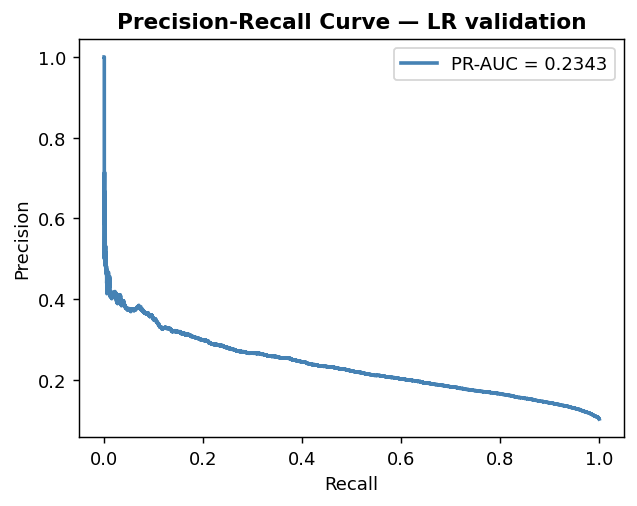

In [10]:
print("\n" + "=" * 60)
print("8. LOGISTIC REGRESSION")
print("=" * 60)

# Small grid search on validation set using fake-class F1 scorer.
# C controls regularisation strength — lower C = more regularisation
# = higher precision, lower recall. Tuned to find best F1 balance.
# solver="lbfgs": correct for dense+sparse mixed features.
# n_jobs omitted — lbfgs ignores it silently.

lr_param_grid = {"C": [0.1, 0.5, 1.0]}

print(f"Grid search: C in {lr_param_grid['C']}")
print("This runs 3-fold CV x 3 values = 9 fits...")

lr_gs = GridSearchCV(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=SEED
    ),
    param_grid=lr_param_grid,
    scoring=f1_fake,          # explicit fake-class F1
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True                # refit best model on full train set
)
lr_gs.fit(X_train, y_train)

print(f"\nGrid search results:")
cv_results = pd.DataFrame(lr_gs.cv_results_)
for _, row in cv_results[["param_C", "mean_test_score",
                            "std_test_score"]].iterrows():
    print(f"  C={row['param_C']:.2f} -> "
          f"CV F1={row['mean_test_score']:.4f} "
          f"(+/-{row['std_test_score']:.4f})")

print(f"\nBest params : {lr_gs.best_params_}")
print(f"Best CV F1  : {lr_gs.best_score_:.4f}")

best_lr = lr_gs.best_estimator_
joblib.dump(best_lr, MODEL_PATH + "logistic_regression.pkl")
print("Saved: logistic_regression.pkl")

# Threshold tuning on validation set
lr_val_proba         = best_lr.predict_proba(X_val)[:, 1]
lr_thresh, lr_val_f1 = tune_threshold(y_val, lr_val_proba,
                                       "Logistic Regression")

# Validation performance at tuned threshold (for reference only)
lr_val_pred = (lr_val_proba >= lr_thresh).astype(int)
print("\nValidation performance (tuned threshold — for reference):")
val_metrics_lr = print_evaluation(
    y_val, lr_val_pred, lr_val_proba,
    "LR — validation", lr_thresh
)
plot_pr_curve(y_val, lr_val_proba, "LR validation", MODEL_PATH)

# ============================================================
# 9. LIGHTGBM — HYPERPARAMETER SEARCH + TRAINING
# ============================================================


9. LIGHTGBM
Grid: {'num_leaves': [31, 64, 128], 'learning_rate': [0.05, 0.1], 'min_child_samples': [20, 50], 'reg_lambda': [0, 1]}
Total combinations: 24
[50]	valid_0's auc: 0.71145
[100]	valid_0's auc: 0.722584
[150]	valid_0's auc: 0.727796
[200]	valid_0's auc: 0.72976
[250]	valid_0's auc: 0.730665
[300]	valid_0's auc: 0.730902
[350]	valid_0's auc: 0.731201
[400]	valid_0's auc: 0.731027
[450]	valid_0's auc: 0.73109
[500]	valid_0's auc: 0.731093

  Threshold tuning (LGBM(nl=31,lr=0.05,mcs=20,rl=0)):
    Search range   : 0.05 -> 0.95 (500 steps)
    Best threshold : 0.5767
    Best val F1    : 0.3046
  nl= 31 lr=0.05 mcs=20 rl=0 | iter= 429 | val F1=0.3046
[50]	valid_0's auc: 0.710643
[100]	valid_0's auc: 0.722746
[150]	valid_0's auc: 0.728005
[200]	valid_0's auc: 0.729825
[250]	valid_0's auc: 0.730207
[300]	valid_0's auc: 0.730702
[350]	valid_0's auc: 0.731054
[400]	valid_0's auc: 0.731102
[450]	valid_0's auc: 0.731447
[500]	valid_0's auc: 0.731202
[550]	valid_0's auc: 0.731102

  Thr

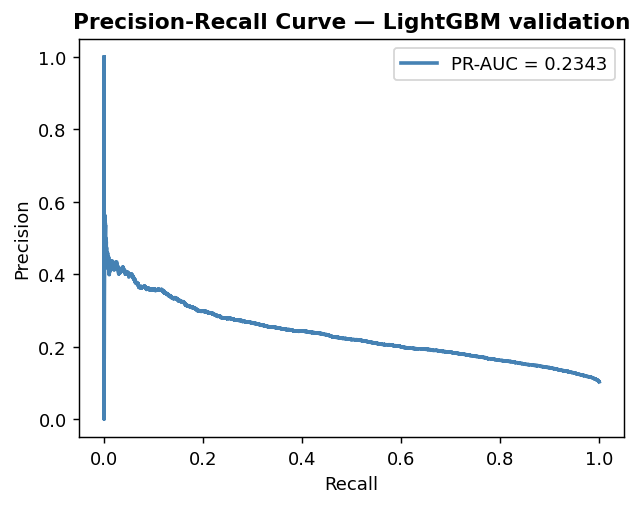

In [11]:
print("\n" + "=" * 60)
print("9. LIGHTGBM")
print("=" * 60)

# Expanded grid — matches B1 and B2 exactly for methodological
# consistency. min_child_samples and reg_lambda are important
# regularisation parameters on imbalanced datasets.
# Total: 3 x 2 x 2 x 2 = 24 combinations.
lgbm_grid = {
    "num_leaves":        [31, 64, 128],
    "learning_rate":     [0.05, 0.1],
    "min_child_samples": [20, 50],
    "reg_lambda":        [0, 1],
}

n_combos = (len(lgbm_grid["num_leaves"]) *
            len(lgbm_grid["learning_rate"]) *
            len(lgbm_grid["min_child_samples"]) *
            len(lgbm_grid["reg_lambda"]))

print(f"Grid: {lgbm_grid}")
print(f"Total combinations: {n_combos}")

best_lgbm_val_f1  = 0.0
best_lgbm_params  = {}
best_lgbm         = None
best_lgbm_thresh  = 0.5
lgbm_grid_results = []

for nl in lgbm_grid["num_leaves"]:
    for lr_val in lgbm_grid["learning_rate"]:
        for mcs in lgbm_grid["min_child_samples"]:
            for rl in lgbm_grid["reg_lambda"]:

                candidate = lgb.LGBMClassifier(
                    n_estimators=1000,
                    learning_rate=lr_val,
                    max_depth=-1,
                    num_leaves=nl,
                    min_child_samples=mcs,
                    reg_lambda=rl,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    scale_pos_weight=scale_pos_weight,
                    metric="auc",
                    random_state=SEED,
                    n_jobs=-1,
                    verbose=-1
                )
                candidate.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=[
                        lgb.early_stopping(
                            stopping_rounds=100, verbose=False
                        ),
                        lgb.log_evaluation(period=50)
                    ]
                )

                val_proba        = candidate.predict_proba(X_val)[:, 1]
                cand_thresh, cand_f1 = tune_threshold(
                    y_val, val_proba,
                    f"LGBM(nl={nl},lr={lr_val},mcs={mcs},rl={rl})"
                )
                print(f"  nl={nl:3d} lr={lr_val:.2f} "
                      f"mcs={mcs:2d} rl={rl} | "
                      f"iter={candidate.best_iteration_:4d} | "
                      f"val F1={cand_f1:.4f}")

                lgbm_grid_results.append({
                    "num_leaves":        nl,
                    "learning_rate":     lr_val,
                    "min_child_samples": mcs,
                    "reg_lambda":        rl,
                    "best_iter":         candidate.best_iteration_,
                    "val_f1":            round(cand_f1,     4),
                    "threshold":         round(cand_thresh, 4),
                })

                if cand_f1 > best_lgbm_val_f1:
                    best_lgbm_val_f1 = cand_f1
                    best_lgbm_params = {
                        "num_leaves":        nl,
                        "learning_rate":     lr_val,
                        "min_child_samples": mcs,
                        "reg_lambda":        rl,
                    }
                    best_lgbm        = candidate
                    best_lgbm_thresh = cand_thresh

print(f"\nBest LGBM params : {best_lgbm_params}")
print(f"Best LGBM val F1 : {best_lgbm_val_f1:.4f}")
print(f"Best threshold   : {best_lgbm_thresh:.4f}")

lgbm_grid_df = pd.DataFrame(lgbm_grid_results)
print("\nFull grid results:")
print(lgbm_grid_df.to_string(index=False))

joblib.dump(best_lgbm, MODEL_PATH + "lightgbm.pkl")
print("\nSaved: lightgbm.pkl")

lgbm_val_proba = best_lgbm.predict_proba(X_val)[:, 1]
lgbm_val_pred  = (lgbm_val_proba >= best_lgbm_thresh).astype(int)
print("\nValidation performance (tuned threshold — for reference):")
val_metrics_lgbm = print_evaluation(
    y_val, lgbm_val_pred, lgbm_val_proba,
    "LightGBM — validation", best_lgbm_thresh
)
plot_pr_curve(y_val, lgbm_val_proba, "LightGBM validation", MODEL_PATH)

# ============================================================
# 10. SAVE THRESHOLDS AND VALIDATION RESULTS
# ============================================================

In [12]:
print("\n" + "=" * 60)
print("10. SAVING THRESHOLDS AND VALIDATION RESULTS")
print("=" * 60)

thresholds = {
    "lr":   lr_thresh,
    "lgbm": best_lgbm_thresh,
}
joblib.dump(thresholds, MODEL_PATH + "thresholds.pkl")
print(f"Saved thresholds : {thresholds}")

val_results_df = pd.DataFrame([val_metrics_lr, val_metrics_lgbm])
val_results_df.to_csv(MODEL_PATH + "results_validation_a1.csv",
                      index=False)
lgbm_grid_df.to_csv(MODEL_PATH + "lgbm_grid_results_a1.csv",
                    index=False)
print("Saved: results_validation_a1.csv")
print("Saved: lgbm_grid_results_a1.csv")



10. SAVING THRESHOLDS AND VALIDATION RESULTS
Saved thresholds : {'lr': 0.6091182364729458, 'lgbm': 0.5856713426853707}
Saved: results_validation_a1.csv
Saved: lgbm_grid_results_a1.csv


# ============================================================
# 11. FINAL TEST EVALUATION
# ============================================================
# Test set touched ONCE — right here.
# Thresholds from validation are applied directly.
# Nothing is re-tuned after seeing test results.
# ============================================================


11. FINAL TEST EVALUATION

───────────────────────────────────────────────────────
  Logistic Regression — test  (threshold = 0.609)
───────────────────────────────────────────────────────
  -- Overall --
  Accuracy         : 0.7912
  F1 macro         : 0.5993
  F1 weighted      : 0.8196
  ROC-AUC          : 0.7424
  PR-AUC           : 0.2382
  -- Genuine class --
  Precision        : 0.9331
  Recall           : 0.8265
  F1-score         : 0.8766
  -- Fake class --
  Precision        : 0.2416
  Recall           : 0.4827
  F1-score         : 0.3221

Classification report:
              precision    recall  f1-score   support

 Genuine (0)     0.9331    0.8265    0.8766     48325
    Fake (1)     0.2416    0.4827    0.3221      5533

    accuracy                         0.7912     53858
   macro avg     0.5874    0.6546    0.5993     53858
weighted avg     0.8621    0.7912    0.8196     53858



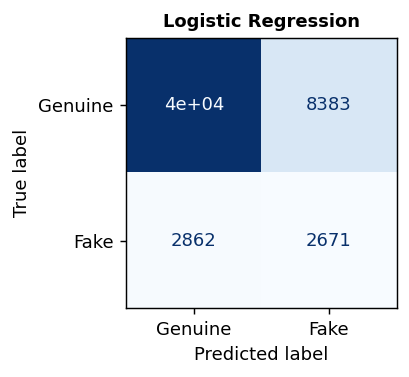

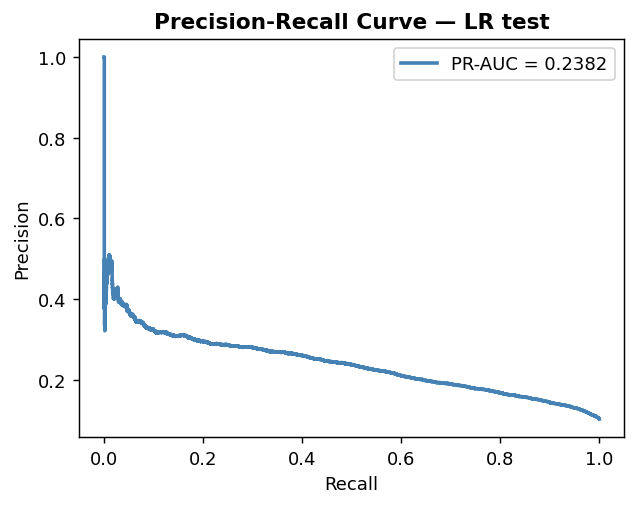


───────────────────────────────────────────────────────
  LightGBM — test  (threshold = 0.586)
───────────────────────────────────────────────────────
  -- Overall --
  Accuracy         : 0.7993
  F1 macro         : 0.5987
  F1 weighted      : 0.8241
  ROC-AUC          : 0.7397
  PR-AUC           : 0.2408
  -- Genuine class --
  Precision        : 0.9301
  Recall           : 0.8395
  F1-score         : 0.8825
  -- Fake class --
  Precision        : 0.2425
  Recall           : 0.4488
  F1-score         : 0.3148

Classification report:
              precision    recall  f1-score   support

 Genuine (0)     0.9301    0.8395    0.8825     48325
    Fake (1)     0.2425    0.4488    0.3148      5533

    accuracy                         0.7993     53858
   macro avg     0.5863    0.6441    0.5987     53858
weighted avg     0.8594    0.7993    0.8241     53858



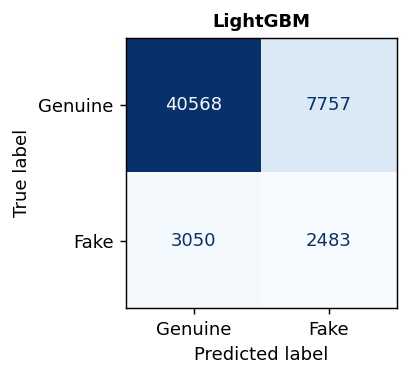

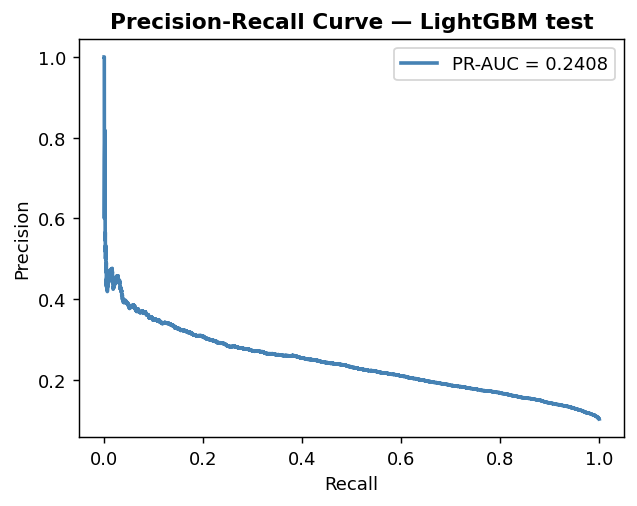

In [13]:
print("\n" + "=" * 60)
print("11. FINAL TEST EVALUATION")
print("=" * 60)

all_results = []

# ── Logistic Regression on test ──────────────────────────────
lr_test_proba = best_lr.predict_proba(X_test)[:, 1]
lr_test_pred  = (lr_test_proba >= lr_thresh).astype(int)

metrics_lr = print_evaluation(
    y_test, lr_test_pred, lr_test_proba,
    "Logistic Regression — test", lr_thresh
)
plot_confusion(y_test, lr_test_pred,
               "Logistic Regression", MODEL_PATH)
plot_pr_curve(y_test, lr_test_proba,
              "LR test", MODEL_PATH)
all_results.append(metrics_lr)

# ── LightGBM on test ─────────────────────────────────────────
lgbm_test_proba = best_lgbm.predict_proba(X_test)[:, 1]
lgbm_test_pred  = (lgbm_test_proba >= best_lgbm_thresh).astype(int)

metrics_lgbm = print_evaluation(
    y_test, lgbm_test_pred, lgbm_test_proba,
    "LightGBM — test", best_lgbm_thresh
)
plot_confusion(y_test, lgbm_test_pred,
               "LightGBM", MODEL_PATH)
plot_pr_curve(y_test, lgbm_test_proba,
              "LightGBM test", MODEL_PATH)
all_results.append(metrics_lgbm)


# ============================================================
# 12. RESULTS TABLE
# ============================================================

In [14]:
print("\n" + "=" * 60)
print("12. RESULTS SUMMARY — EXPERIMENT A1 (TEST SET)")
print("=" * 60)
print("Unfiltered | TF-IDF + metadata\n")

results_df = pd.DataFrame(all_results).set_index("model")
print(results_df.to_string())
print("\nNote: precision / recall / F1 reported for fake class (label=1)")
print("      threshold tuned on validation set, applied once on test")

results_df.to_csv(MODEL_PATH + "results_experiment_a1.csv")
print(f"\nSaved: results_experiment_a1.csv")


12. RESULTS SUMMARY — EXPERIMENT A1 (TEST SET)
Unfiltered | TF-IDF + metadata

                            threshold  accuracy  f1_macro  f1_weighted  roc_auc  pr_auc  precision_gen  recall_gen  f1_gen  precision_fake  recall_fake  f1_fake
model                                                                                                                                                           
Logistic Regression — test      0.609    0.7912    0.5993       0.8196   0.7424  0.2382         0.9331      0.8265  0.8766          0.2416       0.4827   0.3221
LightGBM — test                 0.586    0.7993    0.5987       0.8241   0.7397  0.2408         0.9301      0.8395  0.8825          0.2425       0.4488   0.3148

Note: precision / recall / F1 reported for fake class (label=1)
      threshold tuned on validation set, applied once on test

Saved: results_experiment_a1.csv


# ============================================================
# 13. SUMMARY
# ============================================================

In [15]:
print("\n" + "=" * 60)
print("EXPERIMENT A1 COMPLETE")
print("=" * 60)
print(f"""
Dataset  : yelp_nyc_processed_v2.csv (unfiltered)
  Total      : {len(df):,}
  Genuine    : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)
  Fake       : {(y==1).sum():,} ({y.mean()*100:.1f}%)

Split    : 70 / 15 / 15 stratified (train / val / test)
  Train      : {len(y_train):,}
  Validation : {len(y_val):,}
  Test       : {len(y_test):,}

Features : {X_train.shape[1]} total
  TF-IDF   : {X_tfidf_train.shape[1]} (unigrams+bigrams, fit on train only)
  Metadata : {len(META_COLS)} ({META_COLS})

Imbalance: class_weight="balanced"      (LR)
           scale_pos_weight={scale_pos_weight:.2f}  (LightGBM)

Tuning   : small grid on validation set
  LR best C          : {lr_gs.best_params_['C']}
  LGBM best params   : {best_lgbm_params}
  LR threshold       : {lr_thresh:.4f}
  LGBM threshold     : {best_lgbm_thresh:.4f}

Saved to : {MODEL_PATH}
  logistic_regression.pkl
  lightgbm.pkl
  tfidf_vectorizer.pkl   (+ cached npz matrices)
  meta_scaler.pkl
  thresholds.pkl
  feature_names.pkl
  idx_train / val / test .npy
  results_validation_a1.csv
  lgbm_grid_results_a1.csv
  results_experiment_a1.csv
  confusion_*.png
  pr_curve_*.png

Next     : B1 — filtered + TF-IDF + metadata (no behavioral)
           B2 — filtered + TF-IDF + metadata + behavioral features
""")


EXPERIMENT A1 COMPLETE

Dataset  : yelp_nyc_processed_v2.csv (unfiltered)
  Total      : 359,052
  Genuine    : 322,167 (89.7%)
  Fake       : 36,885 (10.3%)

Split    : 70 / 15 / 15 stratified (train / val / test)
  Train      : 251,336
  Validation : 53,858
  Test       : 53,858

Features : 3006 total
  TF-IDF   : 3000 (unigrams+bigrams, fit on train only)
  Metadata : 6 (['rating', 'review_length', 'extreme_rating', 'review_month', 'review_dayofweek', 'is_weekend'])

Imbalance: class_weight="balanced"      (LR)
           scale_pos_weight=8.73  (LightGBM)

Tuning   : small grid on validation set
  LR best C          : 0.1
  LGBM best params   : {'num_leaves': 128, 'learning_rate': 0.05, 'min_child_samples': 50, 'reg_lambda': 1}
  LR threshold       : 0.6091
  LGBM threshold     : 0.5857

Saved to : /content/drive/MyDrive/FakeReviewProject/experiment_a1/models/
  logistic_regression.pkl
  lightgbm.pkl
  tfidf_vectorizer.pkl   (+ cached npz matrices)
  meta_scaler.pkl
  thresholds.pk